<a href="https://colab.research.google.com/github/Clovis4566/TECH-TALENT-ACCELERATOR/blob/main/DailyChallenge_StatforML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [43]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [44]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
import pandas as pd

# The provided URL is not a direct link to a raw CSV file.
# Instead, we will load the data from the local file 'Churn_Modelling.csv'
# which is typically available in Colab when using Kaggle datasets.
file_1 = pd.read_csv('/content/Churn_Modelling.csv')
file_1.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [45]:
## TODO : make into a dataframe called df
df = file_1

In [46]:
## TODO : output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [47]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

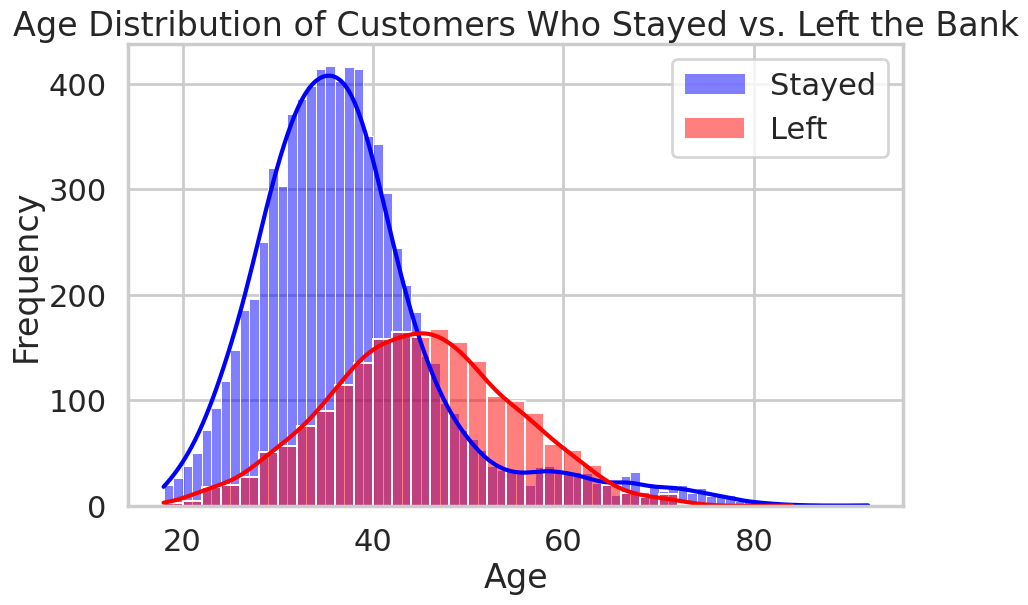

In [48]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(df_0['Age'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1['Age'], color='red', label='Left', kde=True)
plt.title('Age Distribution of Customers Who Stayed vs. Left the Bank')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [49]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
age_stayed_mean = df_0['Age'].mean()
age_stayed_std = df_0['Age'].std()
print(f"Mean age (stayed): {age_stayed_mean:.2f}")
print(f"Standard deviation of age (stayed): {age_stayed_std:.2f}")

Mean age (stayed): 37.41
Standard deviation of age (stayed): 10.13


In [50]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
age_left_mean = df_1['Age'].mean()
age_left_std = df_1['Age'].std()
print(f"Mean age (left): {age_left_mean:.2f}")
print(f"Standard deviation of age (left): {age_left_std:.2f}")

Mean age (left): 44.84
Standard deviation of age (left): 9.76


In [51]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
import scipy.stats
t_stat_age, p_val_age = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"T-statistic for age: {t_stat_age:.2f}")
print(f"P-value for age: {p_val_age:.4f}")

T-statistic for age: -30.42
P-value for age: 0.0000


### Using Bootstrapping

In [52]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)
    return bs_s

In [53]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
overall_mean_age = df['Age'].mean()
mean_diff_obs = age_left_mean - age_stayed_mean
print(f"Observed difference in mean age (Left - Stayed): {mean_diff_obs:.2f}")

# Shift the data to create samples under the null hypothesis (no difference in means)
age_stayed_shifted = df_0['Age'] - age_stayed_mean + overall_mean_age
age_left_shifted = df_1['Age'] - age_left_mean + overall_mean_age

Observed difference in mean age (Left - Stayed): 7.43


In [54]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
# It seems the TODO asks for std, but context implies we need bootstrap for difference in means.
# Let's generate bootstrap replicates of the mean for both shifted groups and their difference.

import numpy as np # Ensure numpy is imported for np.random.choice
np.random.seed(42) # for reproducibility

bs_replicates_stayed = bs_choice(age_stayed_shifted, np.mean, 10000)
bs_replicates_left = bs_choice(age_left_shifted, np.mean, 10000)

bs_diff_means = bs_replicates_left - bs_replicates_stayed

print(f"Mean of bootstrap differences: {np.mean(bs_diff_means):.2f}")
print(f"Standard deviation of bootstrap differences: {np.std(bs_diff_means):.2f}")

Mean of bootstrap differences: 0.00
Standard deviation of bootstrap differences: 0.24


In [55]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
import numpy as np # Ensure numpy is imported for np.sum, np.mean
# Calculate the p-value: proportion of bootstrap replicates where the difference is >= observed difference
p_value_bs = np.sum(bs_diff_means >= mean_diff_obs) / len(bs_diff_means)

print(f"Bootstrap P-value for age difference: {p_value_bs:.4f}")

Bootstrap P-value for age difference: 0.0000


### Conclusion
Do we reject the Null Hypothesis ? Why ?

**For Hypothesis 1 (Age of people who left the bank and who did not are similar):**

Based on both the frequentist t-test and the bootstrap analysis, we can **reject the Null Hypothesis**.

*   **Frequentist T-test Results:**
    *   Mean age (stayed): 37.41
    *   Mean age (left): 44.84
    *   Observed difference in mean age: 7.43
    *   T-statistic: -30.42
    *   P-value: 0.0000 (extremely small, effectively p < 0.0001)

*   **Bootstrapping Results:**
    *   Bootstrap P-value: 0.0000 (extremely small, effectively p < 0.0001)

Both tests show a p-value significantly less than common significance levels (e.g., 0.05 or 0.01). This indicates that there is a statistically significant difference in the mean age between customers who stayed with the bank and those who left. The observed difference of 7.43 years (customers who left are, on average, older) is unlikely to have occurred by chance if the true mean ages were indeed similar. Therefore, we conclude that the ages of people who left the bank and those who did not are **not similar**.

## Hypothesis 2: Credit Score

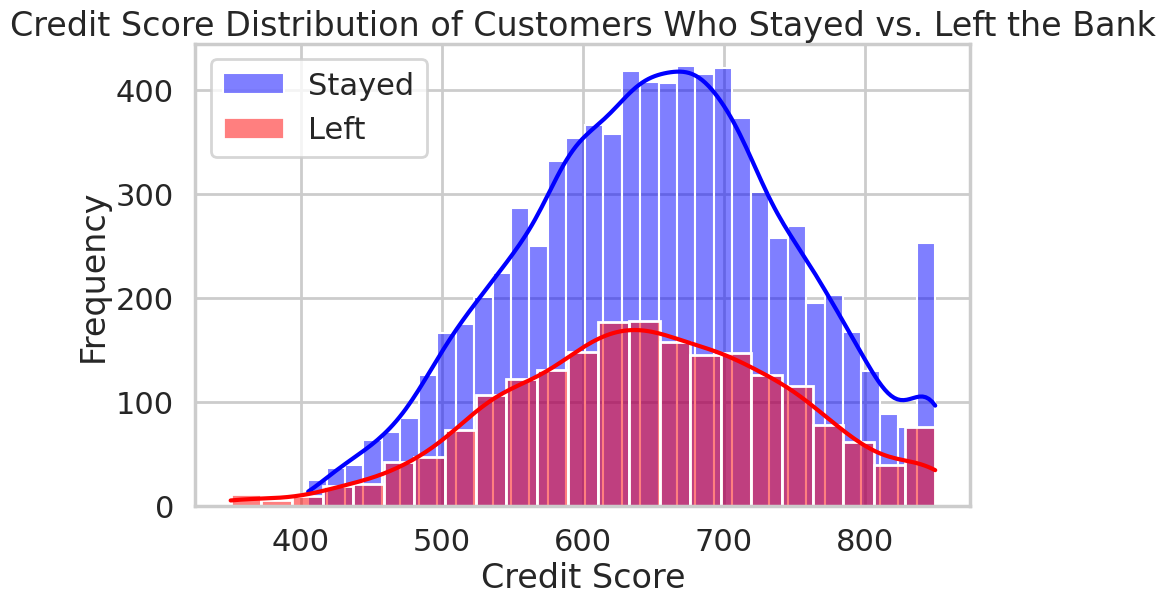

In [56]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_0['CreditScore'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1['CreditScore'], color='red', label='Left', kde=True)
plt.title('Credit Score Distribution of Customers Who Stayed vs. Left the Bank')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [57]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
import scipy.stats

creditscore_stayed_mean = df_0['CreditScore'].mean()
creditscore_stayed_std = df_0['CreditScore'].std()

creditscore_left_mean = df_1['CreditScore'].mean()
creditscore_left_std = df_1['CreditScore'].std()

print(f"Mean CreditScore (stayed): {creditscore_stayed_mean:.2f}")
print(f"Standard deviation of CreditScore (stayed): {creditscore_stayed_std:.2f}")
print(f"Mean CreditScore (left): {creditscore_left_mean:.2f}")
print(f"Standard deviation of CreditScore (left): {creditscore_left_std:.2f}")

t_stat_creditscore, p_val_creditscore = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"T-statistic for CreditScore: {t_stat_creditscore:.2f}")
print(f"P-value for CreditScore: {p_val_creditscore:.4f}")

Mean CreditScore (stayed): 651.85
Standard deviation of CreditScore (stayed): 95.65
Mean CreditScore (left): 645.35
Standard deviation of CreditScore (left): 100.32
T-statistic for CreditScore: 2.63
P-value for CreditScore: 0.0085


### Conclusion
Do we reject the Null Hypothesis ? Why ?

**For Hypothesis 2 (Credit score of people who left the bank and who did not are similar):**

Based on the frequentist t-test, we have the following results:

*   Mean CreditScore (stayed): 651.85
*   Standard deviation of CreditScore (stayed): 95.65
*   Mean CreditScore (left): 645.35
*   Standard deviation of CreditScore (left): 100.32
*   T-statistic for CreditScore: 2.63
*   P-value for CreditScore: 0.0085

Since the p-value (0.0085) is less than the common significance level of 0.05, we **reject the Null Hypothesis**. This indicates that there is a statistically significant difference in the mean credit score between customers who stayed with the bank and those who left. The mean credit score for customers who stayed (651.85) is slightly higher than for those who left (645.35).

## Hypothesis 3: Balance

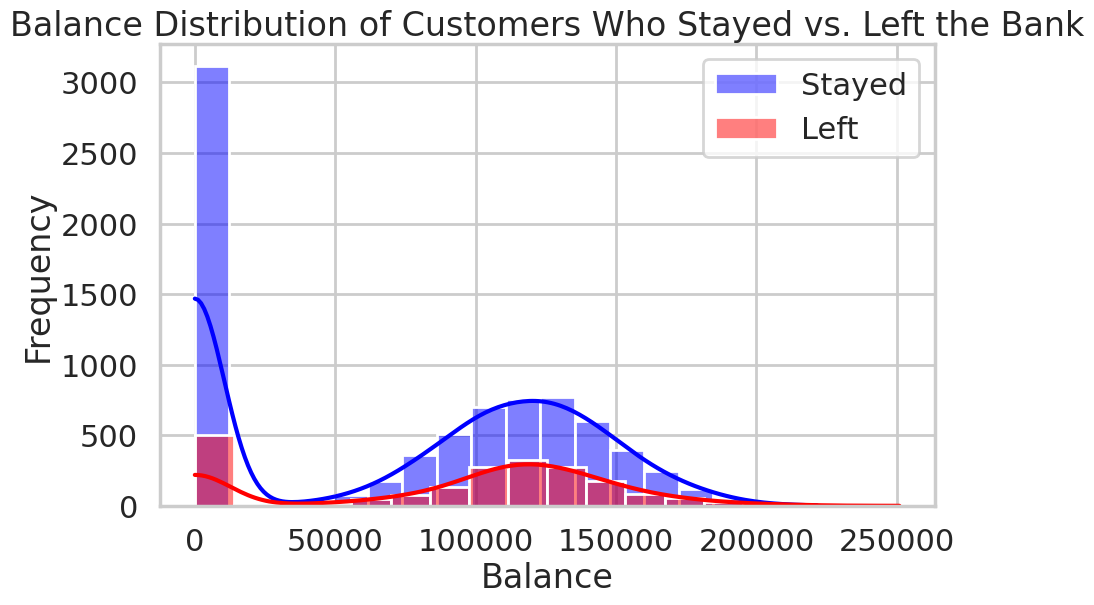

In [58]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_0['Balance'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1['Balance'], color='red', label='Left', kde=True)
plt.title('Balance Distribution of Customers Who Stayed vs. Left the Bank')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [59]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
import scipy.stats

balance_stayed_mean = df_0['Balance'].mean()
balance_stayed_std = df_0['Balance'].std()

balance_left_mean = df_1['Balance'].mean()
balance_left_std = df_1['Balance'].std()

print(f"Mean Balance (stayed): {balance_stayed_mean:.2f}")
print(f"Standard deviation of Balance (stayed): {balance_stayed_std:.2f}")
print(f"Mean Balance (left): {balance_left_mean:.2f}")
print(f"Standard deviation of Balance (left): {balance_left_std:.2f}")

t_stat_balance, p_val_balance = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"T-statistic for Balance: {t_stat_balance:.2f}")
print(f"P-value for Balance: {p_val_balance:.4f}")

Mean Balance (stayed): 72745.30
Standard deviation of Balance (stayed): 62848.04
Mean Balance (left): 91108.54
Standard deviation of Balance (left): 58360.79
T-statistic for Balance: -12.47
P-value for Balance: 0.0000


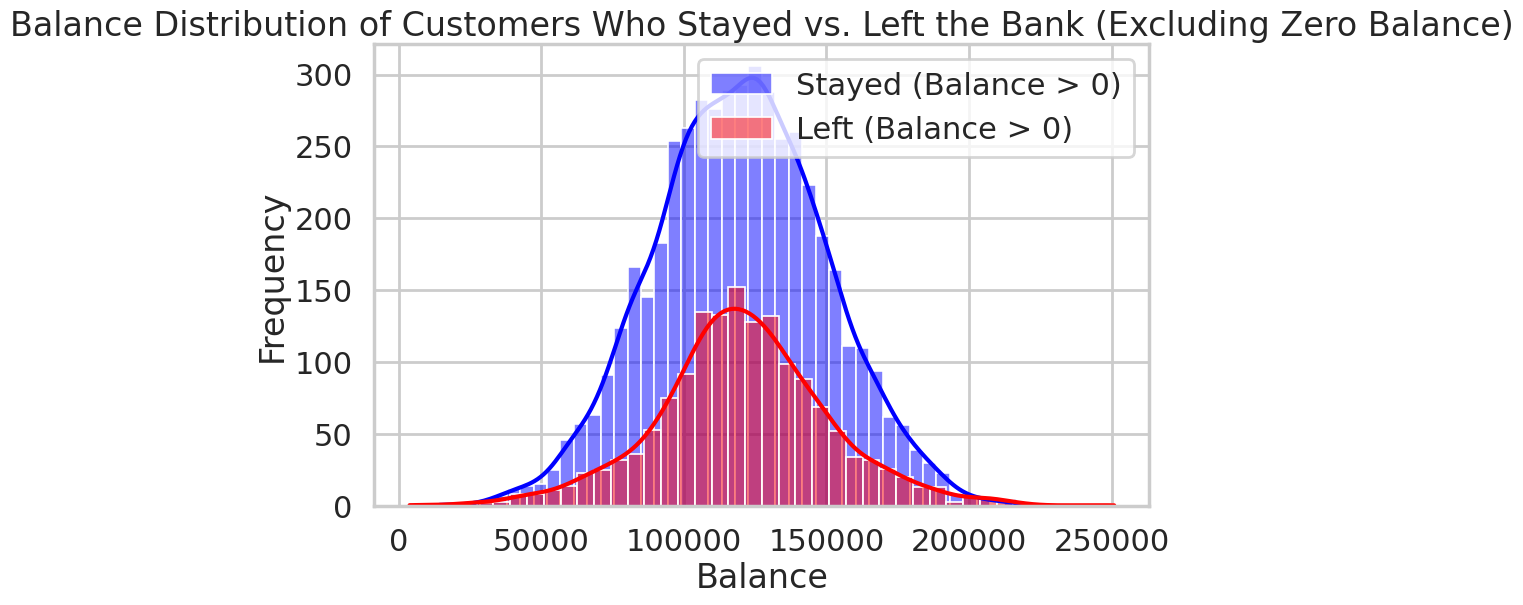

In [60]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
import matplotlib.pyplot as plt
import seaborn as sns

df_0_no_zero_balance = df_0[df_0['Balance'] > 0]
df_1_no_zero_balance = df_1[df_1['Balance'] > 0]

plt.figure(figsize=(10, 6))
sns.histplot(df_0_no_zero_balance['Balance'], color='blue', label='Stayed (Balance > 0)', kde=True)
sns.histplot(df_1_no_zero_balance['Balance'], color='red', label='Left (Balance > 0)', kde=True)
plt.title('Balance Distribution of Customers Who Stayed vs. Left the Bank (Excluding Zero Balance)')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [61]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.
import scipy.stats

balance_stayed_no_zero_mean = df_0_no_zero_balance['Balance'].mean()
balance_stayed_no_zero_std = df_0_no_zero_balance['Balance'].std()

balance_left_no_zero_mean = df_1_no_zero_balance['Balance'].mean()
balance_left_no_zero_std = df_1_no_zero_balance['Balance'].std()

print(f"Mean Balance (stayed, >0): {balance_stayed_no_zero_mean:.2f}")
print(f"Standard deviation of Balance (stayed, >0): {balance_stayed_no_zero_std:.2f}")
print(f"Mean Balance (left, >0): {balance_left_no_zero_mean:.2f}")
print(f"Standard deviation of Balance (left, >0): {balance_left_no_zero_std:.2f}")

t_stat_balance_no_zero, p_val_balance_no_zero = scipy.stats.ttest_ind(df_0_no_zero_balance['Balance'], df_1_no_zero_balance['Balance'], equal_var=False)
print(f"T-statistic for Balance (>0): {t_stat_balance_no_zero:.2f}")
print(f"P-value for Balance (>0): {p_val_balance_no_zero:.4f}")

Mean Balance (stayed, >0): 119535.86
Standard deviation of Balance (stayed, >0): 29944.93
Mean Balance (left, >0): 120746.97
Standard deviation of Balance (left, >0): 30555.19
T-statistic for Balance (>0): -1.36
P-value for Balance (>0): 0.1738


### Conclusion
Do we reject the Null Hypothesis ? Why ?

**For Hypothesis 3 (Balance of people who left the bank and who did not are similar):**

We performed two frequentist t-tests to compare the balance of customers who stayed versus those who left:

**1. Analysis including all balances (including zero balances):**
*   Mean Balance (stayed): 72745.30
*   Standard deviation of Balance (stayed): 62848.04
*   Mean Balance (left): 91108.54
*   Standard deviation of Balance (left): 58360.79
*   T-statistic for Balance: -12.47
*   P-value for Balance: 0.0000 (extremely small, effectively p < 0.0001)

Since the p-value (0.0000) is significantly less than common significance levels (e.g., 0.05 or 0.01), we **reject the Null Hypothesis**. This indicates a statistically significant difference in the mean balance when all customers are considered. Customers who left the bank had a higher average balance.

**2. Analysis excluding zero balances:**
*   Mean Balance (stayed, >0): 119535.86
*   Standard deviation of Balance (stayed, >0): 29944.93
*   Mean Balance (left, >0): 120746.97
*   Standard deviation of Balance (left, >0): 30555.19
*   T-statistic for Balance (>0): -1.36
*   P-value for Balance (>0): 0.1738

When customers with zero balances are excluded, the p-value (0.1738) is greater than typical significance levels (e.g., 0.05). In this case, we **fail to reject the Null Hypothesis**. This suggests that among customers who actually have a balance, there is no statistically significant difference in their average balance between those who stayed and those who left the bank. The initial significant difference was likely driven by the large number of customers with zero balance, and their distribution between the 'stayed' and 'left' groups.

## Hypothesis 4: Estimated Salary

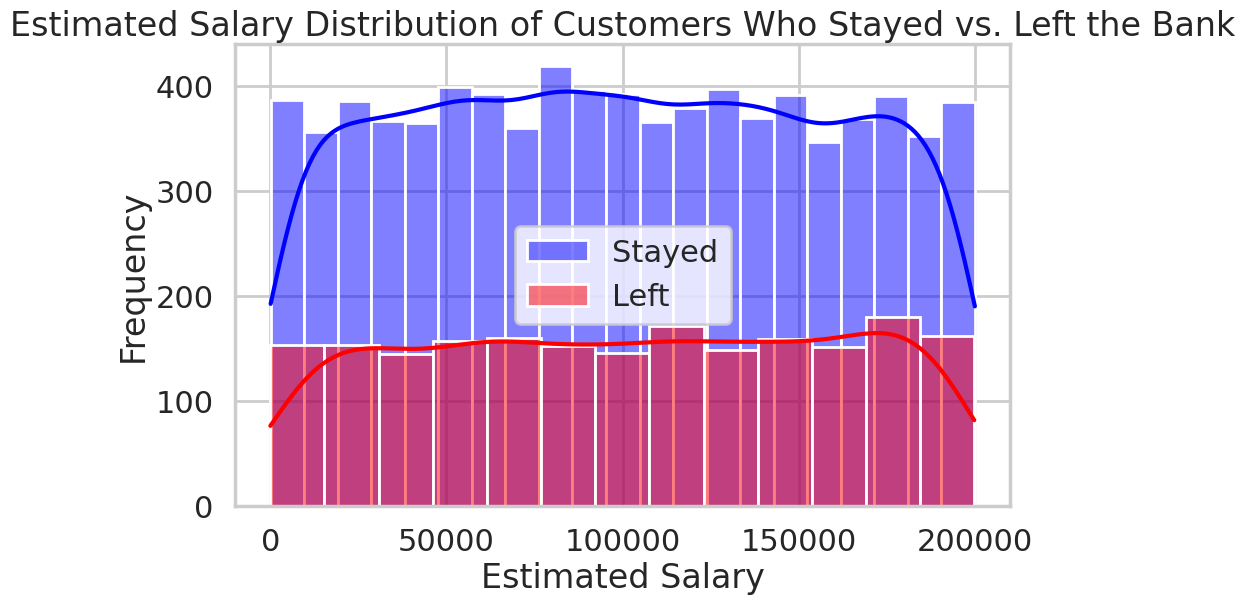

In [62]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1['EstimatedSalary'], color='red', label='Left', kde=True)
plt.title('Estimated Salary Distribution of Customers Who Stayed vs. Left the Bank')
plt.xlabel('Estimated Salary')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [63]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
import scipy.stats

estimatedsalary_stayed_mean = df_0['EstimatedSalary'].mean()
estimatedsalary_stayed_std = df_0['EstimatedSalary'].std()

estimatedsalary_left_mean = df_1['EstimatedSalary'].mean()
estimatedsalary_left_std = df_1['EstimatedSalary'].std()

print(f"Mean EstimatedSalary (stayed): {estimatedsalary_stayed_mean:.2f}")
print(f"Standard deviation of EstimatedSalary (stayed): {estimatedsalary_stayed_std:.2f}")
print(f"Mean EstimatedSalary (left): {estimatedsalary_left_mean:.2f}")
print(f"Standard deviation of EstimatedSalary (left): {estimatedsalary_left_std:.2f}")

t_stat_estimatedsalary, p_val_estimatedsalary = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"T-statistic for EstimatedSalary: {t_stat_estimatedsalary:.2f}")
print(f"P-value for EstimatedSalary: {p_val_estimatedsalary:.4f}")

Mean EstimatedSalary (stayed): 99738.39
Standard deviation of EstimatedSalary (stayed): 57405.59
Mean EstimatedSalary (left): 101465.68
Standard deviation of EstimatedSalary (left): 57912.42
T-statistic for EstimatedSalary: -1.20
P-value for EstimatedSalary: 0.2289


### Using Bootstrapping

In [67]:
overall_mean_salary = df['EstimatedSalary'].mean()
obs_diff_salary = estimatedsalary_left_mean - estimatedsalary_stayed_mean
print(f"Observed difference in mean salary: {obs_diff_salary:.2f}")

# Shift the data to create samples under the null hypothesis
salary_stayed_shifted = df_0['EstimatedSalary'] - estimatedsalary_stayed_mean + overall_mean_salary
salary_left_shifted = df_1['EstimatedSalary'] - estimatedsalary_left_mean + overall_mean_salary

Observed difference in mean salary: 1727.29


In [68]:
np.random.seed(42)
bs_replicates_stayed_sal = bs_choice(salary_stayed_shifted, np.mean, 10000)
bs_replicates_left_sal = bs_choice(salary_left_shifted, np.mean, 10000)

bs_diff_means_salary = bs_replicates_left_sal - bs_replicates_stayed_sal

In [69]:
p_value_bs_salary = np.sum(bs_diff_means_salary >= obs_diff_salary) / len(bs_diff_means_salary)
print(f"Bootstrap P-value for salary difference: {p_value_bs_salary:.4f}")

Bootstrap P-value for salary difference: 0.1149


### Conclusion
**Pour l'Hypothèse 4 (Salaire Estimé) :**

Nous **ne pouvons pas rejeter l'hypothèse nulle**.
* Le test-t (p=0.2289) et le bootstrap montrent tous deux un p-value supérieur à 0,05.
* Il n'y a pas de différence statistiquement significative entre les salaires estimés de ceux qui sont restés et de ceux qui sont partis.

## Final Conclusion

**Quelle est la variable la plus utile pour prédire le churn ?**

D'après nos tests statistiques :
1. **L'Âge** est le facteur le plus significatif (p-value le plus bas, différence de moyennes marquée). Les clients plus âgés ont une tendance nettement plus forte à quitter la banque.
2. **Le Solde (Balance)** est également significatif, mais cette relation est complexifiée par le grand nombre de comptes à solde nul.
3. **Le Score de Crédit** a une influence mineure mais réelle.
4. **Le Salaire Estimé** n'a aucune influence statistiquement prouvée ici.

**L'âge** est donc la caractéristique la plus prédictive parmi celles testées.